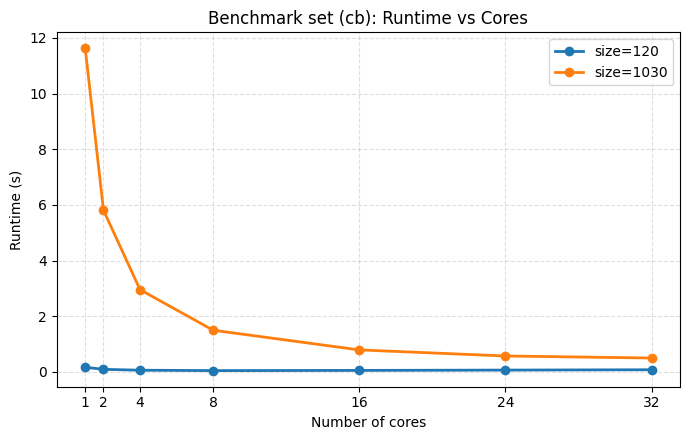

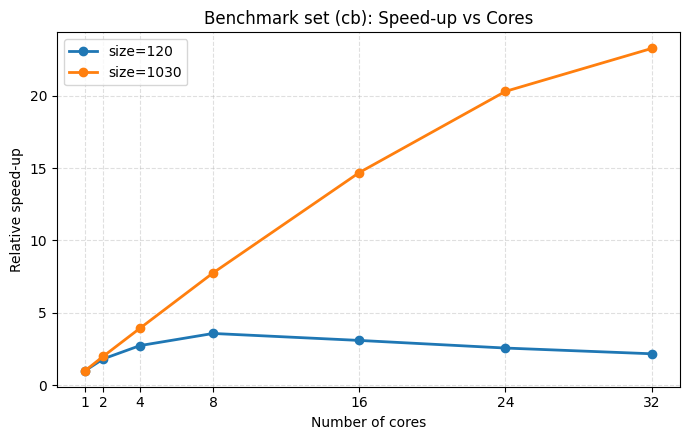

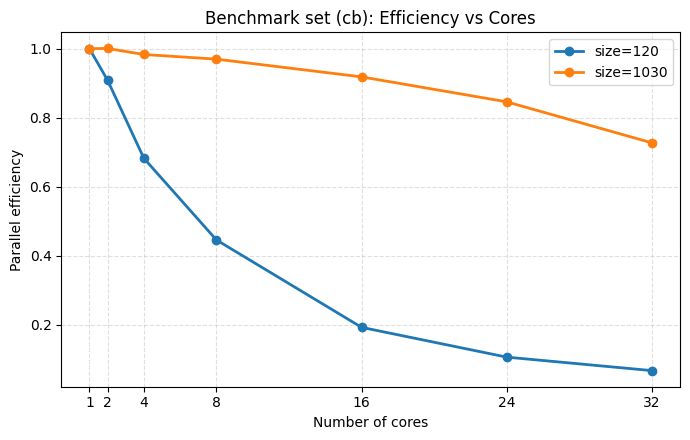

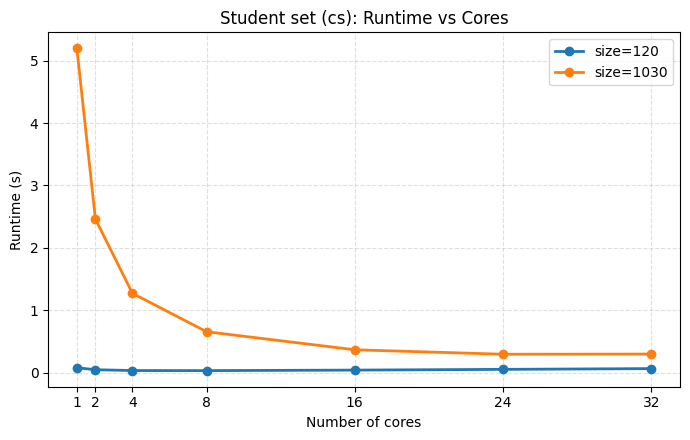

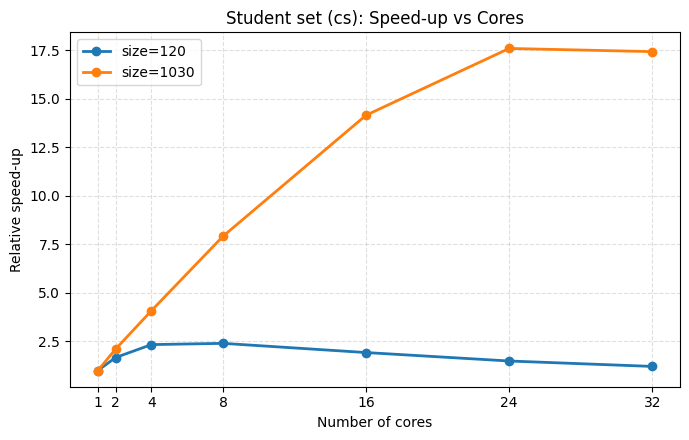

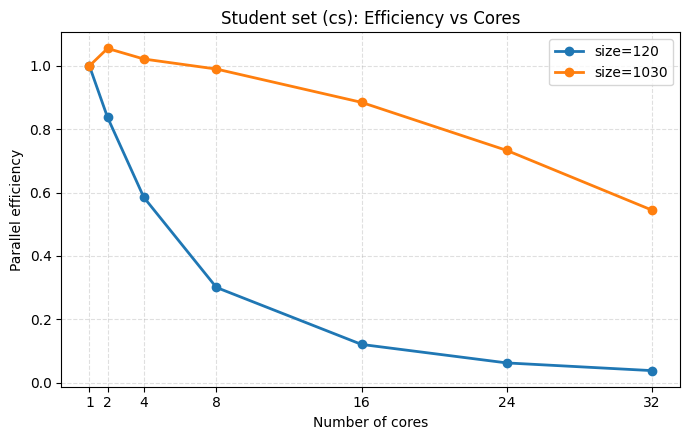

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_cb = pd.read_csv("results_cb.csv")
df_cs = pd.read_csv("results_cs.csv")

# Clean types just in case
for df in (df_cb, df_cs):
    df["size"] = df["size"].astype(int)
    df["nprocs"] = df["nprocs"].astype(int)

def plot_metric(df, metric, ylabel, title, outfile=None):
    plt.figure(figsize=(7, 4.5))
    
    for size in sorted(df["size"].unique()):
        part = df[df["size"] == size].sort_values("nprocs")
        plt.plot(part["nprocs"], part[metric], marker="o", linewidth=2, label=f"size={size}")
    
    plt.xlabel("Number of cores")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks([1, 2, 4, 8, 16, 24, 32])
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    
    if outfile:
        plt.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()

# --- cb plots ---
plot_metric(df_cb, "mean_time", "Runtime (s)", "Benchmark set (cb): Runtime vs Cores", "cb_runtime.png")
plot_metric(df_cb, "speedup", "Relative speed-up", "Benchmark set (cb): Speed-up vs Cores", "cb_speedup.png")
plot_metric(df_cb, "efficiency", "Parallel efficiency", "Benchmark set (cb): Efficiency vs Cores", "cb_efficiency.png")

# --- cs plots ---
plot_metric(df_cs, "mean_time", "Runtime (s)", "Student set (cs): Runtime vs Cores", "cs_runtime.png")
plot_metric(df_cs, "speedup", "Relative speed-up", "Student set (cs): Speed-up vs Cores", "cs_speedup.png")
plot_metric(df_cs, "efficiency", "Parallel efficiency", "Student set (cs): Efficiency vs Cores", "cs_efficiency.png")

## plots for 2.3 and 2.4

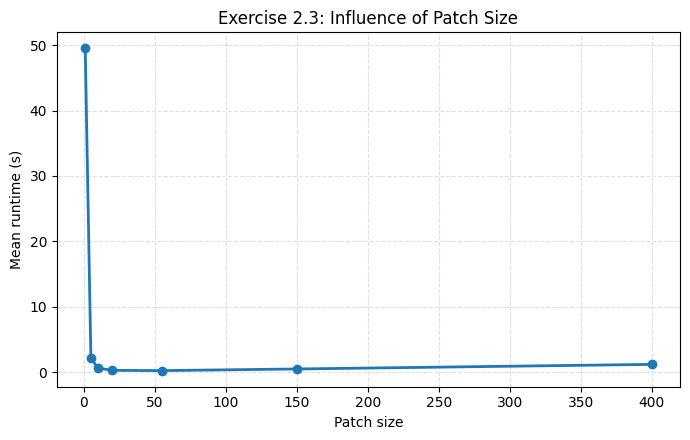

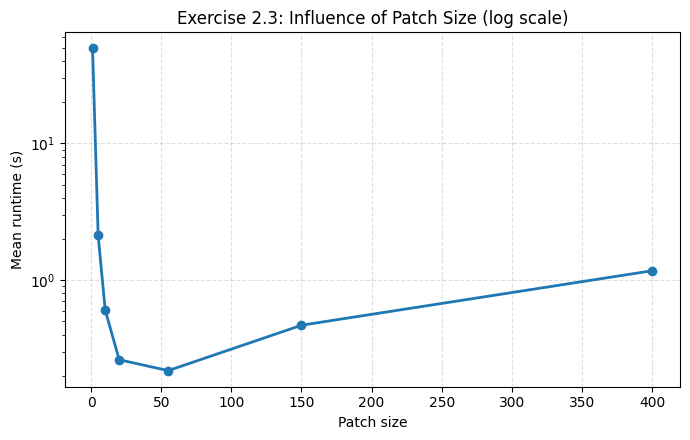

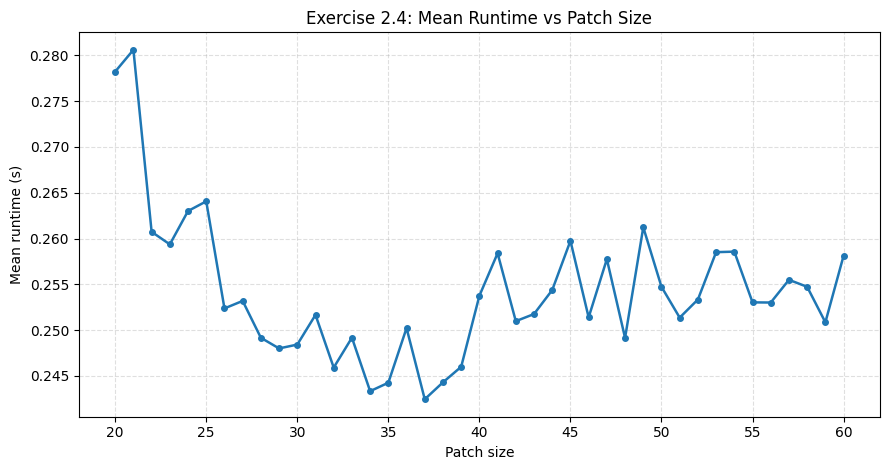

size         900.000000
nprocs        20.000000
patch         37.000000
mean_time      0.242436
Name: 17, dtype: float64


In [ ]:
df23 = pd.read_csv("results_patch_2_3.csv")
df24 = pd.read_csv("results_patch_2_4.csv")

# Sort just to be safe
df23 = df23.sort_values("patch")
df24 = df24.sort_values("patch")


plt.figure(figsize=(7, 4.5))
plt.plot(df23["patch"], df23["mean_time"], marker="o", linewidth=2)
plt.xlabel("Patch size")
plt.ylabel("Mean runtime (s)")
plt.title("Exercise 2.3: Influence of Patch Size")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Optional: same plot with log y-scale, useful because patch=1 is much larger
plt.figure(figsize=(7, 4.5))
plt.plot(df23["patch"], df23["mean_time"], marker="o", linewidth=2)
plt.xlabel("Patch size")
plt.ylabel("Mean runtime (s)")
plt.title("Exercise 2.3: Influence of Patch Size (log scale)")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4.8))
plt.plot(df24["patch"], df24["mean_time"], marker="o", markersize=4, linewidth=1.8)
plt.xlabel("Patch size")
plt.ylabel("Mean runtime (s)")
plt.title("Exercise 2.4: Mean Runtime vs Patch Size")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Optional: show best patch numerically
best_row = df24.loc[df24["mean_time"].idxmin()]
print(best_row)